### Learning JAX by building models!

#### Imports and preprocessing

In [ ]:
# Run it if you didn't already.
# !conda install flax ml_dtypes optax orbax-checkpoint chex -c conda-forge
# pip install grain scikit-learn

In [1]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.keys())
print(f"{digits.data.shape=}")
print(f"{digits.target.shape=}")

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
digits.data.shape=(1797, 64)
digits.target.shape=(1797,)


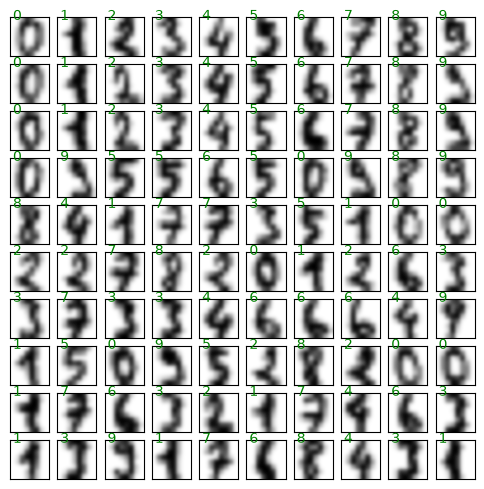

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(6, 6),subplot_kw={'xticks':[], 'yticks':[]},)
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="binary", interpolation='gaussian')
    ax.text(0.1, 0.1, str(digits.target[i]), color="green")

In [4]:
from sklearn.model_selection import train_test_split
splits = train_test_split(digits.images, digits.target, random_state = 0)

In [22]:
import jax.numpy as jnp
train_images, test_images, train_labels, test_labels = map(jnp.asarray, splits)

In [23]:
print(f"{train_images.shape=}, {train_labels.shape=}")
print(f"{test_images.shape=}, {test_labels.shape=}")

train_images.shape=(1347, 8, 8), train_labels.shape=(1347,)
test_images.shape=(450, 8, 8), test_labels.shape=(450,)


#### Creating the model

In [24]:
from flax import nnx

class MLP(nnx.Module):
    def __init__(self, din: int = 64, dhidden: int = 256, dout: int = 10, *, rngs=nnx.Rngs):
        self.din = din
        self.layer1 = nnx.Linear(din, dhidden, rngs = rngs)
        self.layer2 = nnx.Linear(dhidden, dhidden, rngs = rngs)
        self.layer3 = nnx.Linear(dhidden, dout, rngs = rngs)

    def __call__(self, x):
        x = x.reshape(x.shape[0], self.din)
        x = nnx.selu(self.layer1(x))
        x = nnx.selu(self.layer2(x))
        x = self.layer3(x)
        return x

model = MLP(rngs = nnx.Rngs(0))
nnx.display(model)

In [34]:
import jax, optax
optimizer = nnx.ModelAndOptimizer(model, optax.adamw(learning_rate=0.05))

In [35]:
def loss_fun(model: nnx.Module, x: jax.Array, y: jax.Array):
    logits = model(x)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits = logits, labels = y).mean()
    return loss, logits

@nnx.jit
def train_step(model: nnx.Module, optimizer: nnx.Optimizer, x: jax.Array, y: jax.Array):
    grad_fun = jax.grad(loss_fun, has_aux = True)
    grads, logits = grad_fun(model, x, y)
    optimizer.update(grads)

In [39]:
# training steps
for i in range(301):
    train_step(model, optimizer, train_images, train_labels)
    if i % 50 == 0:
        loss, _ = loss_fun(model, test_images, test_labels)
        print(f"Epoch = {i}: Loss: {loss:.4f}")

Epoch = 0: Loss: 0.5435
Epoch = 50: Loss: 0.5431
Epoch = 100: Loss: 0.5431
Epoch = 150: Loss: 0.5432
Epoch = 200: Loss: 0.5432
Epoch = 250: Loss: 0.5436
Epoch = 300: Loss: 0.5430


In [57]:
predicted_labels = model(test_images).argmax(axis=1)
num_matches = jnp.count_nonzero(predicted_labels == test_labels)
num_total = len(test_labels)

accuracy = num_matches / num_total
print(f"Total test examples: {num_total}, Correct predictions: {num_matches}, Accuracy: {accuracy:4%}")

Total test examples: 450, Correct predictions: 438, Accuracy: 97.333336%


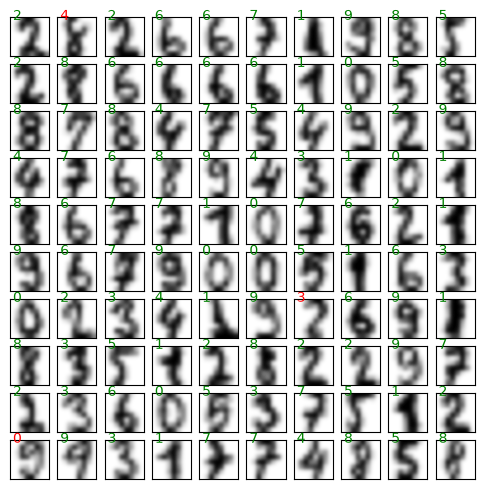

In [63]:
fig, axes = plt.subplots(10, 10, figsize=(6, 6),subplot_kw={'xticks':[], 'yticks':[]},)
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap="binary", interpolation='gaussian')
    color = "green" if predicted_labels[i] == test_labels[i] else "red"
    ax.text(0.1, 0.1, str(predicted_labels[i]), color=color)